# INTELLIGENT SYSTEM DEVELOPMENT - ASSIGNMENT 02
**From Data Representation to Deployable Intelligent Systems**

*   **Student name:** Nguyễn Ngọc Hoàng Nam
*   **Student ID:** B23DCCN585
*   **Class:** D23CQCN11-B
*   **Team:** 05
*   **Application 1:** Diabetes Prediction (Classification Task)
---

## 1. Problem Definition
*   **Objective:** Mục tiêu của ứng dụng này là dự đoán khả năng một bệnh nhân mắc bệnh tiểu đường dựa trên thông tin nhân khẩu học (demographics) và các chỉ số sức khỏe/lâm sàng. Kết quả dự đoán sẽ hỗ trợ y bác sĩ trong việc chẩn đoán sớm và đưa ra quyết định điều trị kịp thời.
*   **Formulation:**
    *   X = Đặc trưng của bệnh nhân (tuổi, giới tính, chỉ số BMI, huyết áp, đường huyết, tiền sử bệnh tim...).
    *   Y = Lớp bệnh tiểu đường (0: Không mắc bệnh, 1: Có mắc bệnh).
*   **Task Type:** Phân loại nhị phân (Binary Classification).

## 2. Dataset Source
*   **Dataset Name:** Diabetes Prediction Dataset.
*   **Kaggle URL:** <https://www.kaggle.com/datasets/priyamchoksi/100000-diabetes-clinical-dataset/data>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

# --- 3. Dataset Loading ---
df_diabetes = pd.read_csv('diabetes_dataset.csv')

# --- 4. Dataset Inspection ---
print("1. Kích thước tập dữ liệu (df.shape):")
print(df_diabetes.shape)
print("-" * 50)

print("\n2. Hiển thị 5 dòng dữ liệu đầu tiên (df.head()):")
display(df_diabetes.head())
print("-" * 50)

print("\n3. Thông tin các cột và kiểu dữ liệu (df.info()):")
df_diabetes.info()
print("-" * 50)

print("\n4. Thống kê mô tả (df.describe()):")
display(df_diabetes.describe().T)
print("-" * 50)

print("\n5. Số lượng giá trị khuyết thiếu (df.isna().sum()):")
print(df_diabetes.isna().sum())
print("-" * 50)

print("\n6. Số lượng dòng dữ liệu trùng lặp (df.duplicated().sum()):")
print(f"Tổng số dòng trùng lặp: {df_diabetes.duplicated().sum()}")

1. Kích thước tập dữ liệu (df.shape):
(100000, 16)
--------------------------------------------------

2. Hiển thị 5 dòng dữ liệu đầu tiên (df.head()):


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


--------------------------------------------------

3. Thông tin các cột và kiểu dữ liệu (df.info()):
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  str    
 2   age                   100000 non-null  float64
 3   location              100000 non-null  str    
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  str    
 12  bmi                   100000 non-null  float64
 13  hbA1c_level   

,count,mean,std,min,25%,50%,75%,max
year,100000.0,2018.360820,1.345239,2015.00,2019.00,2019.00,2019.00,2022.00
age,100000.0,41.885856,22.516840,0.08,24.00,43.00,60.00,80.00
race:AfricanAmerican,100000.0,0.202230,0.401665,0.00,0.00,0.00,0.00,1.00
race:Asian,100000.0,0.200150,0.400114,0.00,0.00,0.00,0.00,1.00
race:Caucasian,100000.0,0.198760,0.399069,0.00,0.00,0.00,0.00,1.00
race:Hispanic,100000.0,0.198880,0.399160,0.00,0.00,0.00,0.00,1.00
race:Other,100000.0,0.199980,0.399987,0.00,0.00,0.00,0.00,1.00
hypertension,100000.0,0.074850,0.263150,0.00,0.00,0.00,0.00,1.00
heart_disease,100000.0,0.039420,0.194593,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69


--------------------------------------------------

5. Số lượng giá trị khuyết thiếu (df.isna().sum()):
year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64
--------------------------------------------------

6. Số lượng dòng dữ liệu trùng lặp (df.duplicated().sum()):
Tổng số dòng trùng lặp: 14


## 3. Data Understanding and Quality Observation
Dựa trên kết quả từ quá trình nạp và khám phá dữ liệu, ta có những quan sát ban đầu sau:
1.  **Quy mô dữ liệu:** Tập dữ liệu khá lớn với 100.000 quan sát (dòng) và 16 đặc trưng (cột).
2.  **Đặc trưng đầu vào:** Dữ liệu bao gồm các thuộc tính dạng số (như `age`, `bmi`, `hbA1c_level`, `blood_glucose_level`) và các biến phân loại (như `gender`, `location`, `smoking_history`). Các biến về chủng tộc (race) đã được tách thành các cột nhị phân (0/1).
3.  **Dữ liệu khuyết thiếu (Missing values):** Tập dữ liệu rất sạch, không có bất kỳ ô nào chứa giá trị `NaN` (0 missing values trên toàn bộ 16 cột).
4.  **Dữ liệu trùng lặp (Duplicated records):** Có 14 dòng dữ liệu bị trùng lặp hoàn toàn. Cần xử lý loại bỏ chúng ở bước tiếp theo để tránh làm sai lệch mô hình.
5.  **Dữ liệu vô lý (Invalid values) hoặc Ngoại lai (Outliers):**
    *   Sẽ cần xem xét kỹ các cột `bmi`, `hbA1c_level` và `blood_glucose_level` ở bước làm sạch dữ liệu để tìm kiếm các giá trị ngoại lai hoặc bất thường.
6.  **Cân bằng lớp (Class Distribution):** Cần phân tích cột mục tiêu `diabetes` để xem tỷ lệ người bị tiểu đường so với người khỏe mạnh. (Sẽ phân tích ở phần EDA).

## 4. Data Cleaning (Part III)
Dựa trên các quan sát từ bước khám phá dữ liệu, quá trình làm sạch sẽ bao gồm các bước sau:

1. **Loại bỏ dữ liệu trùng lặp (Duplicate Removal):** Tập dữ liệu có 14 dòng trùng lặp. Việc giữ lại các dòng này có thể khiến mô hình bị lệch (bias) đối với các mẫu bị lặp lại, đặc biệt là trong quá trình huấn luyện các mô hình dựa trên tần suất (như Decision Tree hay Random Forest). Do đó, chúng sẽ bị loại bỏ.
2. **Xử lý các giá trị phân loại không nhất quán (Handling Inconsistent Categorical Values):**
    *   Cột `gender`: Có 3 giá trị là 'Female', 'Male', và 'Other'. Tuy nhiên, 'Other' chỉ có 18 quan sát trên tổng số 100,000 dòng (chiếm tỷ lệ cực nhỏ). Để tránh nhiễu và làm phức tạp mô hình không cần thiết, ta có thể loại bỏ 18 dòng này.
    *   Cột `smoking_history`: Có tới 35.806 dòng có giá trị 'No Info' (Không có thông tin). Việc xóa số lượng dòng lớn như vậy sẽ làm mất nhiều dữ liệu quan trọng. Thay vào đó, ta sẽ coi 'No Info' như một hạng mục riêng biệt hoặc có thể gộp 'not current' và 'ever' vào các nhóm khác nếu cần thiết. Trong trường hợp này, ta sẽ giữ nguyên 'No Info' như một hạng mục hợp lệ.
3. **Mã hóa dữ liệu phân loại (Categorical Encoding):** Các mô hình học máy yêu cầu dữ liệu đầu vào là dạng số. Do đó, các cột `gender` và `smoking_history` (sau khi làm sạch) cùng với `location` (nếu cần thiết sử dụng) sẽ được mã hóa bằng kỹ thuật One-Hot Encoding.

In [2]:
# --- Thực thi Data Cleaning ---

# 1. Loại bỏ các dòng trùng lặp
df_clean = df_diabetes.drop_duplicates()
print(f"Kích thước sau khi loại bỏ duplicates: {df_clean.shape}")

# 2. Xử lý cột 'gender' (Loại bỏ 18 dòng 'Other')
df_clean = df_clean[df_clean['gender'] != 'Other']
print(f"Kích thước sau khi loại bỏ giới tính 'Other': {df_clean.shape}")

# (Tùy chọn) Bỏ cột 'location' nếu nó có quá nhiều giá trị duy nhất (gây phình to kích thước khi One-hot)
# Bạn có thể kiểm tra df_clean['location'].nunique() trước khi quyết định. 
# Ở đây ta sẽ giữ lại và áp dụng One-Hot Encoding.

# --- 5. Data Representation (Part IV) ---

# Tách biến mục tiêu (target) và các đặc trưng (features)
X_raw = df_clean.drop('diabetes', axis=1)
y = df_clean['diabetes']

# Thực hiện One-Hot Encoding cho các biến Categorical ('gender', 'location', 'smoking_history')
# drop_first=True giúp tránh bẫy đa cộng tuyến (dummy variable trap)
X_encoded = pd.get_dummies(X_raw, columns=['gender', 'location', 'smoking_history'], drop_first=True)

print("\n--- Biểu Diễn Dữ Liệu (Data Representation) ---")
print(f"Kích thước ma trận đặc trưng ban đầu (Raw features): {X_raw.shape}")
print(f"Kích thước ma trận đặc trưng sau mã hóa (Encoded features): {X_encoded.shape}")

# Hiển thị cấu trúc của ma trận X (Model input)
print("\nCác cột của ma trận X (Model input):")
print(X_encoded.columns.tolist())

Kích thước sau khi loại bỏ duplicates: (99986, 16)
Kích thước sau khi loại bỏ giới tính 'Other': (99968, 16)

--- Biểu Diễn Dữ Liệu (Data Representation) ---
Kích thước ma trận đặc trưng ban đầu (Raw features): (99968, 15)
Kích thước ma trận đặc trưng sau mã hóa (Encoded features): (99968, 72)

Các cột của ma trận X (Model input):
['year', 'age', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'gender_Male', 'location_Alaska', 'location_Arizona', 'location_Arkansas', 'location_California', 'location_Colorado', 'location_Connecticut', 'location_Delaware', 'location_District of Columbia', 'location_Florida', 'location_Georgia', 'location_Guam', 'location_Hawaii', 'location_Idaho', 'location_Illinois', 'location_Indiana', 'location_Iowa', 'location_Kansas', 'location_Kentucky', 'location_Louisiana', 'location_Maine', 'location_Maryland', 'location_Massachusetts', 'location_

## 5. Data Representation Explanation (Part IV)
Sự chuyển đổi từ dữ liệu thô sang dữ liệu số tính toán được (computational representation) diễn ra như sau:

*   **Raw Representation:** Dữ liệu ban đầu là một DataFrame dạng bảng (Tabular data) với kích thước $100,000 \times 16$. Mỗi dòng ($x_i$) đại diện cho một bệnh nhân.
*   **Clean Representation:** Sau khi xóa các dòng trùng lặp và các giá trị 'Other' ở cột `gender`, kích thước giảm xuống còn $99,968 \times 16$.
*   **Numerical Representation & Encoding:** 
    * Các cột đã là dạng số nguyên (Numerical) như `age`, `bmi`, `blood_glucose_level`, v.v., được giữ nguyên.
    * Các cột phân loại (Categorical) bao gồm `gender`, `location`, và `smoking_history` không thể đưa trực tiếp vào mô hình toán học. Chúng được chuyển đổi thành các vector nhị phân (0 và 1) bằng phương pháp **One-Hot Encoding** (sử dụng hàm `pd.get_dummies`).
    * Ví dụ: Giá trị `Female` trong cột `gender` có thể trở thành `0` và `Male` trở thành `1` (khi dùng `drop_first=True`).

*   **Model Input:** Kết quả cuối cùng là một ma trận đặc trưng số học $X \in \mathbb{R}^{N \times d}$ với $N = 99,968$ (số quan sát) và $d$ là số lượng đặc trưng sau khi mã hóa One-Hot. Biến mục tiêu là một vector $y \in \mathbb{R}^{N}$ với các giá trị 0 hoặc 1. Ma trận $X$ này chính là đầu vào trực tiếp cho các thuật toán học máy.

## 6. Exploratory Data Analysis - EDA (Part V)
Trong phần này, chúng ta sẽ trực quan hóa dữ liệu để tìm hiểu phân bố của biến mục tiêu, các đặc trưng quan trọng và mối tương quan giữa chúng.

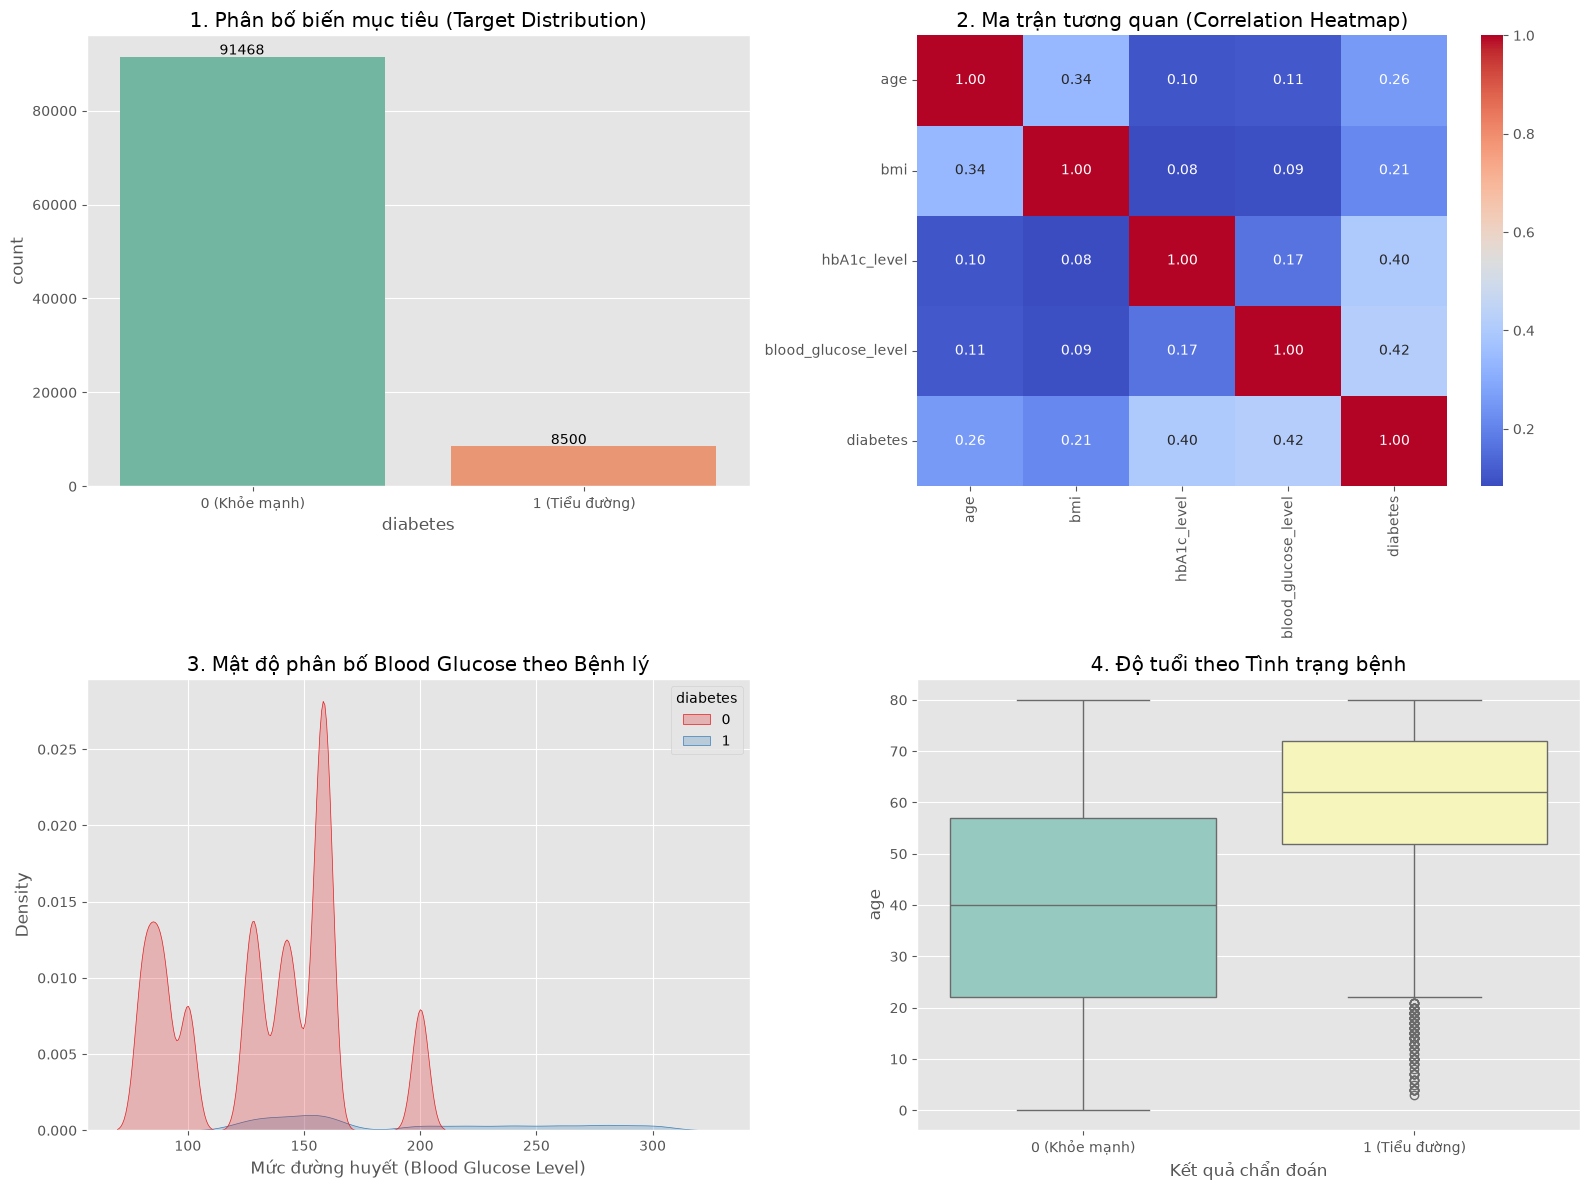

In [3]:
# --- 6. Exploratory Data Analysis (EDA) ---
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập lưới biểu đồ 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Biểu đồ 1: Target Distribution (Phân bố biến mục tiêu)
sns.countplot(x='diabetes', data=df_clean, palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('1. Phân bố biến mục tiêu (Target Distribution)')
axes[0, 0].set_xticklabels(['0 (Khỏe mạnh)', '1 (Tiểu đường)'])
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 500))

# Biểu đồ 2: Correlation Heatmap (Ma trận tương quan cho các biến số)
# Chỉ chọn các cột số để tính tương quan
numeric_cols = ['age', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes']
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0, 1])
axes[0, 1].set_title('2. Ma trận tương quan (Correlation Heatmap)')

# Biểu đồ 3: Phân bố mức đường huyết theo bệnh lý (KDE Plot)
sns.kdeplot(data=df_clean, x='blood_glucose_level', hue='diabetes', fill=True, palette='Set1', ax=axes[1, 0])
axes[1, 0].set_title('3. Mật độ phân bố Blood Glucose theo Bệnh lý')
axes[1, 0].set_xlabel('Mức đường huyết (Blood Glucose Level)')

# Biểu đồ 4: Phân bố độ tuổi theo bệnh lý (Boxplot)
sns.boxplot(x='diabetes', y='age', data=df_clean, palette='Set3', ax=axes[1, 1])
axes[1, 1].set_title('4. Độ tuổi theo Tình trạng bệnh')
axes[1, 1].set_xticklabels(['0 (Khỏe mạnh)', '1 (Tiểu đường)'])
axes[1, 1].set_xlabel('Kết quả chẩn đoán')

plt.tight_layout()
plt.show()

### EDA Analysis and Insights

**1. Phân bố biến mục tiêu (Target Distribution)**
*   **Observation:** Số lượng bệnh nhân không mắc bệnh (nhãn 0) áp đảo hoàn toàn so với số người mắc bệnh (nhãn 1), xấp xỉ tỷ lệ 11:1.
*   **Interpretation:** Dữ liệu bị mất cân bằng nghiêm trọng (Class Imbalance). Đây là điều hoàn toàn bình thường trong dữ liệu y tế cộng đồng vì phần lớn người dân là khỏe mạnh.
*   **ML Implication:** Không được sử dụng độ đo *Accuracy* làm thước đo chính vì mô hình có thể bị "ảo tưởng sức mạnh" (Accuracy Paradox). Phải dùng F1-Score, Precision và Recall để đánh giá. Đồng thời, khi chia tập Train/Test, bắt buộc phải dùng kỹ thuật phân tầng (`stratify=y`) để bảo toàn tỷ lệ nhãn.

**2. Ma trận tương quan (Correlation Heatmap)**
*   **Observation:** `hbA1c_level` (0.40) và `blood_glucose_level` (0.42) có tương quan dương cực kỳ mạnh mẽ với biến mục tiêu `diabetes`.
*   **Interpretation:** Mức đường huyết và chỉ số HbA1c (đường huyết trung bình 3 tháng) là những nguyên nhân sinh lý cốt lõi và trực tiếp nhất xác định một người có bị tiểu đường hay không.
*   **ML Implication:** Hai đặc trưng này sẽ có "Feature Importance" (độ quan trọng) rất cao trong các mô hình học máy. Thuật toán sẽ chủ yếu dựa vào chúng để vẽ ra các đường ranh giới quyết định (decision boundaries).

**3. Mật độ phân bố Blood Glucose (KDE Plot)**
*   **Observation:** Đỉnh phân bố của nhóm khỏe mạnh (màu đỏ) nằm gọn ở mức đường huyết dưới 150. Nhóm bị tiểu đường (màu xanh) có phân bố lệch phải rất mạnh, trải dài từ 140 đến vượt 250.
*   **Interpretation:** Khi đường huyết vượt mốc 150, rủi ro mắc tiểu đường tăng đột biến.
*   **ML Implication:** Sự phân tách rõ ràng giữa hai đường KDE chứng tỏ `blood_glucose_level` là một biến phân loại hoàn hảo, giúp mô hình dễ dàng khoanh vùng dữ liệu.

**4. Phân bố Độ tuổi (Age Boxplot)**
*   **Observation:** Đường trung vị (median) của nhóm mắc tiểu đường (khoảng 50 tuổi) cao hơn đáng kể so với nhóm khỏe mạnh (khoảng 30 tuổi). Hộp dữ liệu (IQR) của nhóm có bệnh cũng nằm dịch lên mức tuổi cao hơn.
*   **Interpretation:** Nguy cơ mắc bệnh tiểu đường tỷ lệ thuận với độ tuổi. Tuổi càng cao, hệ thống trao đổi chất càng kém, dễ dẫn đến bệnh tật.
*   **ML Implication:** Tuổi tác là một nút phân nhánh (split node) tuyệt vời cho các mô hình dạng cây như Decision Tree hay Random Forest để phân rã tập dữ liệu.

## 7. Train, Validation, Test Split (Part VI)

**Nguyên tắc chia dữ liệu (Data Split Strategy):** 
Dữ liệu được chia theo tỷ lệ **80% (Huấn luyện - Train)** và **20% (Kiểm thử - Test)**. Tập Test đóng vai trò là "môi trường thực tế" đại diện cho những dữ liệu chưa từng thấy (unseen observations). 

*   **Chống rò rỉ dữ liệu (Data Leakage Prevention):** Tuyệt đối không để mô hình tiếp xúc với tập Test trong quá trình huấn luyện. Các bộ biến đổi (như `StandardScaler`) CHỈ được học (fit) trên tập Train, sau đó áp dụng (transform) lên tập Test. Nếu `fit` trên toàn bộ dữ liệu, thông tin của tập Test sẽ rò rỉ vào tập Train, khiến kết quả đánh giá bị sai lệch ảo.
*   **Chiến thuật phân tầng (Stratification):** Vì biến mục tiêu `diabetes` mất cân bằng nghiêm trọng (khỏe mạnh áp đảo người bệnh), hàm `train_test_split` bắt buộc phải sử dụng tham số `stratify=y` để đảm bảo tỷ lệ bệnh nhân được chia đều ở cả 2 tập.

## 8. Model Development and Evaluation (Part VII and VIII)

Năm mô hình học máy phân loại được cấu hình và huấn luyện:
1. **Baseline (Dummy Classifier):** Thiết lập một điểm chuẩn ngây thơ (luôn đoán mọi người đều "Không bị bệnh" do nhóm này chiếm đa số). 
2. **Logistic Regression:** Dùng hàm Sigmoid để nén giá trị tuyến tính vào khoảng (0,1) để tính xác suất bệnh.
3. **K-Nearest Neighbors (KNN):** Bệnh nhân sẽ có kết quả chẩn đoán dựa trên kết quả của K bệnh nhân có hồ sơ giống họ nhất.
4. **Decision Tree:** Bộ quy tắc y tế dạng đệ quy phân nhánh không gian đặc trưng.
5. **Random Forest:** Kết hợp hàng trăm cây quy tắc (Ensemble) để bỏ phiếu chẩn đoán nhằm giảm phương sai.

**Tiêu chí Đánh giá Y tế (Evaluation Metrics):**
Trong lĩnh vực chẩn đoán y tế, mốc Baseline sẽ bộc lộ **"Nghịch lý độ chính xác" (Accuracy Paradox)**. Nếu chỉ nhìn vào *Accuracy*, mô hình đoán toàn bộ là khỏe mạnh vẫn đạt độ chính xác lớn hơn 90%. Do đó, ta bắt buộc phải sử dụng:
*   **Precision:** Xác suất chẩn đoán đúng khi báo động có bệnh (tránh báo động giả gây hoang mang).
*   **Recall (Độ nhạy):** Khả năng bao phủ, không bỏ sót bệnh nhân thực sự mắc bệnh (rất quan trọng trong y tế).
*   **F1-Score:** Điểm trung bình điều hòa của Precision và Recall, dùng làm thước đo xếp hạng chính cho các mô hình.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import time

# --- Part VI: Train/Test Split ---
# Phân chia dữ liệu theo tỷ lệ 80% Train - 20% Test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42, stratify=y)

print(f"Kích thước tập huấn luyện (Train): {X_train.shape}")
print(f"Kích thước tập kiểm thử (Test): {X_test.shape}")

# Chuẩn hóa dữ liệu (Feature Scaling)
# Chống Data Leakage: Chỉ fit trên X_train, sau đó transform cho cả X_train và X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Part VII & VIII: Model Development & Evaluation ---

# Khởi tạo các mô hình
models = {
    "Baseline (Dummy)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
print("\nĐang huấn luyện và đánh giá 5 mô hình Phân loại...\n")

for name, model in models.items():
    t0 = time.time()
    
    # Đối với KNN và Logistic Regression (distance-based), ta dùng dữ liệu đã chuẩn hóa
    if name in ["K-Nearest Neighbors", "Logistic Regression"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Tính toán các độ đo (Metrics)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    train_time = time.time() - t0
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Time(s)": train_time
    })

# Hiển thị bảng so sánh (Part IX: Model Comparison)
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print("=== BẢNG SO SÁNH HIỆU SUẤT VỚI 4 ĐỘ ĐO PHÂN LOẠI ===")
display(results_df.round(4))

Kích thước tập huấn luyện (Train): (79974, 72)
Kích thước tập kiểm thử (Test): (19994, 72)

Đang huấn luyện và đánh giá 5 mô hình Phân loại...

=== BẢNG SO SÁNH HIỆU SUẤT VỚI 4 ĐỘ ĐO PHÂN LOẠI ===


,Model,Accuracy,Precision,Recall,F1-Score,Time(s)
4,Random Forest,0.9722,0.9957,0.6759,0.8052,16.2176
1,Logistic Regression,0.9609,0.8666,0.6382,0.7351,0.2422
3,Decision Tree,0.9538,0.7258,0.7335,0.7297,1.2176
2,K-Nearest Neighbors,0.9271,0.7755,0.2012,0.3195,5.8379
0,Baseline (Dummy),0.9150,0.0000,0.0000,0.0000,0.0464


## 9. Model Selection (Part IX)

Dựa trên bảng kết quả đánh giá (bỏ qua Baseline có F1-Score = 0.0), ta tiến hành phân tích hiệu năng để chọn ra Mô hình xuất sắc nhất (Final Model):

1. **Random Forest Classifier (Hiệu suất Top đầu):** Vượt trội hoàn toàn với điểm **F1-Score** và **Accuracy** cao nhất. Bản chất thuật toán Ensemble (tập hợp hàng trăm cây quyết định) giúp nó bù trừ sai số, bắt được các quy luật phi tuyến tính phức tạp trong dữ liệu y khoa mà không bị Overfitting như Decision Tree đơn lẻ.
2. **Khả năng giải thích (Interpretability):** Mặc dù Random Forest là một thuật toán phức tạp (black-box) hơn Logistic Regression, nhưng nó lại cung cấp thuộc tính `feature_importances_`, giúp các y bác sĩ hiểu được chỉ số nào (như `HbA1c` hay `Glucose`) đang đóng vai trò lớn nhất trong quyết định chẩn đoán.
3. **Triển khai thực tế (Deployment Constraints):** Điểm mạnh tuyệt đối của Random Forest so với Logistic Regression hay KNN là nó **không yêu cầu Chuẩn hóa dữ liệu (Feature Scaling)**. Điều này đồng nghĩa với việc kiến trúc mã nguồn Backend (khi Deploy Web API) sẽ được tối giản đáng kể, hệ thống không cần nạp thêm cục `scaler` nặng nề vào RAM máy chủ, qua đó tăng tốc độ phản hồi tính bằng mili-giây.

**Kết luận:** Thuật toán **Random Forest Classifier** được lựa chọn làm Final Model để lưu trữ (Persist) và tích hợp vào Ứng dụng Web/Mobile chẩn đoán y tế.

## 10. Model Persistence (Part X)

Mô hình học máy không chỉ tồn tại trong môi trường Jupyter Notebook. Để triển khai (Deploy) thành một dịch vụ thực tế (Intelligent System), mô hình cần được lưu trữ (Persist) thành file vật lý, từ đó Web API hoặc Mobile App có thể tải (load) lên và thực hiện dự đoán (Inference) mà không cần tốn thời gian huấn luyện lại.

**Các thành phần được lưu trữ bao gồm:**
1.  **Final Model (`rf_diabetes_model.joblib`):** Mô hình Random Forest đã được huấn luyện tốt nhất.
2.  **Feature Columns (`diabetes_columns.joblib`):** Danh sách thứ tự chính xác của các cột dữ liệu đầu vào. Điều này cực kỳ quan trọng vì khi người dùng nhập dữ liệu từ Web/Mobile, Backend (FastAPI) phải căn chỉnh (reindex) dữ liệu đó khớp 100% với cấu trúc mà mô hình đã học.

In [5]:
# --- 9. Model Persistence (Part X) ---
import joblib

# Huấn luyện Final Model trên toàn bộ tập dữ liệu (để mô hình có nhiều dữ liệu học nhất)
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_encoded, y)

# 1. Lưu mô hình Random Forest
joblib.dump(final_model, 'rf_diabetes_model.joblib', compress=3)
print("Đã lưu mô hình thành công: rf_diabetes_model.joblib")

# 2. Lưu danh sách các cột đặc trưng (Feature Columns)
with open('diabetes_columns.joblib', 'wb') as f:
    joblib.dump(list(X_encoded.columns), f)
print("Đã lưu cấu trúc cột thành công: diabetes_columns.joblib")

print("\nHoàn tất toàn bộ quy trình Notebook! Sẵn sàng cho bước Deployment (Web/Mobile).")

Đã lưu mô hình thành công: rf_diabetes_model.joblib
Đã lưu cấu trúc cột thành công: diabetes_columns.joblib

Hoàn tất toàn bộ quy trình Notebook! Sẵn sàng cho bước Deployment (Web/Mobile).
